In [ ]:
#check if the file is there
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv") # run the data

df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [ ]:
#Goal: understand your dataset structure check if there is null or duplicated data
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


np.int64(0)

In [ ]:
#Headline analysis
df["headline"].isnull().sum()
df[["headline", "headline_length", "word_count"]].head()


,headline,headline_length,word_count
0,Stocks That Hit 52-Week Highs On Friday,39.0,7.0
1,Stocks That Hit 52-Week Highs On Wednesday,42.0,7.0
2,71 Biggest Movers From Friday,29.0,5.0
3,46 Stocks Moving In Friday's Mid-Day Session,44.0,7.0
4,B of A Securities Maintains Neutral on Agilent...,87.0,14.0


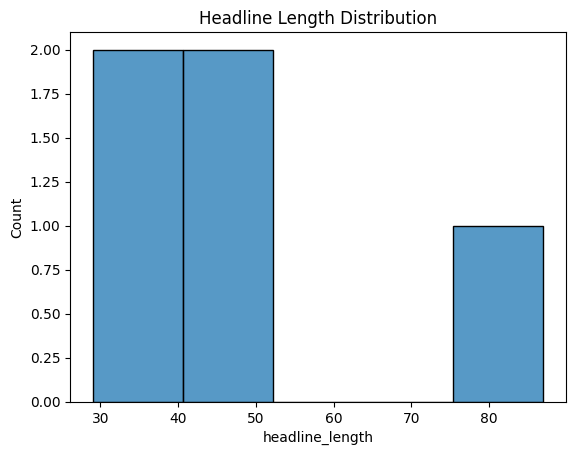

In [ ]:
### Insight: Headline Length Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["headline_length"])
plt.title("Headline Length Distribution")
plt.show()
#The distribution of headline lengths shows that most financial news headlines fall within a moderate range (approximately 29–87 characters). This indicates that financial news is designed to be concise and quickly readable for investors and traders. Very short or extremely long headlines are less common, suggesting a standardized style of reporting in financial journalism.


In [39]:
df["publisher"].value_counts().head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

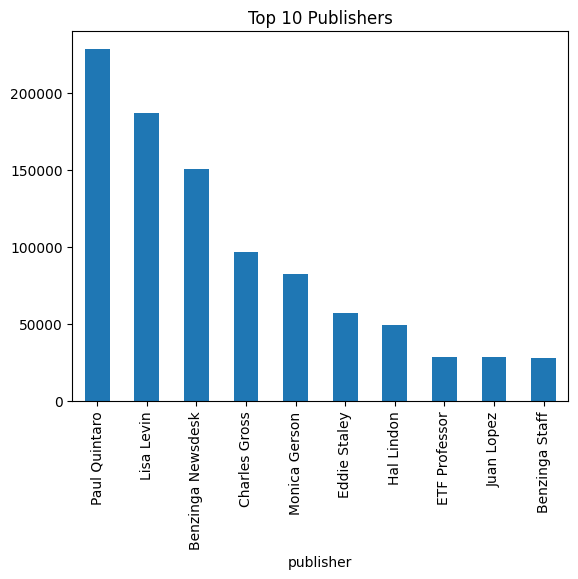

In [ ]:
#Publisher Analysis
import matplotlib.pyplot as plt

df["publisher"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Publishers")
plt.show()
#A small number of publishers contribute a large portion of financial news, indicating concentration of financial information sources.

In [41]:
#Time analysis
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].dt.date.value_counts().head()

date
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
Name: count, dtype: int64

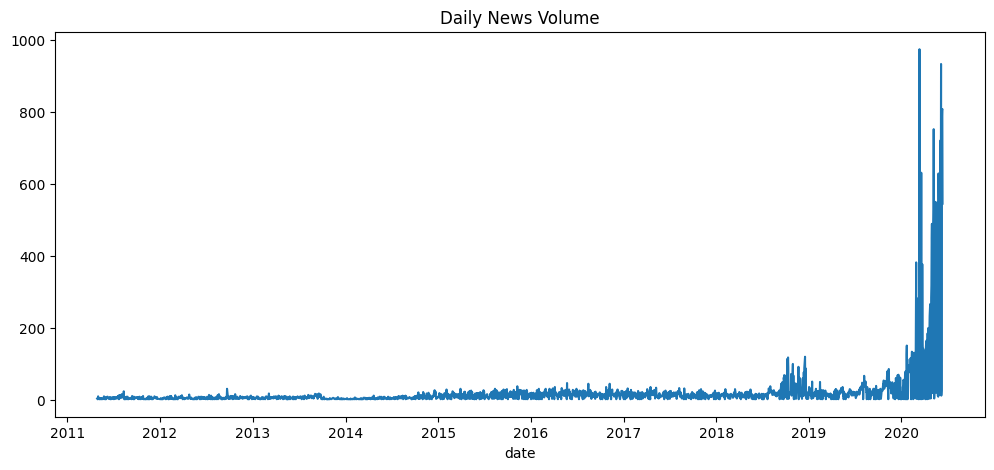

In [ ]:
#daily news visualization
import matplotlib.pyplot as plt

daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()
#News volume spikes at specific times, suggesting alignment with market opening and closing periods.

In [ ]:
#### Insight: TF-IDF Keyword Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=10)
X = vectorizer.fit_transform(df["headline"])

print(vectorizer.get_feature_names_out())

#The most important terms in financial news headlines include words such as "earnings", "EPS", "stocks", "market", and "sales". These indicate that financial news is primarily focused on company performance, stock movements, and analyst expectations rather than general news topics.

['earnings' 'eps' 'est' 'market' 'reports' 'sales' 'shares' 'stocks'
 'update' 'vs']
